# Supp Fig 1 — top discriminative genes

Reproduces **SuppFig1** by inlining the actual generating code from the source notebooks/scripts. Set the paths in the config cell, then run top-to-bottom. Cost tags: 🟢 light · 🟡 moderate · 🔴 heavy.

> Excluded (non-code): Supp Fig 1b SLC2A1/MUC4 IHC images.

## Configuration — edit the paths, then run

In [ ]:
import os, sys, glob, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
warnings.filterwarnings("ignore")
try:
    import scanpy as sc
    import anndata as ad
except Exception as e:
    print("[note] scanpy/anndata not available:", e)

# ── EDIT THESE PATHS to match your environment ──
REPO_ROOT     = Path("/path/to/spatnic")          # this repository
BACKUP_ROOT   = Path("/path/to/backup")           # integrate_adata_filtered.h5ad, galaxy scores, Liver meta
DATA_ROOT     = Path("/path/to/data")             # GxD concat, lung annotated, c2l refs, spatnic_models, GxD_Xenium
BENCHMARK_DB  = Path("/path/to/benchmark_db")     # Xenium/VisiumHD/MERFISH/CosMx + adata_hvg_*
VISIUMHD_ROOT = Path("/path/to/VisiumHD")         # Visium HD ADC track
WEIGHTS_DIR   = Path.home() / ".spatnic" / "weights"

# ── Derived ──
NB     = REPO_ROOT / "notebooks"
COMP   = NB / "comparison_results"
VHD    = VISIUMHD_ROOT
MODELS = DATA_ROOT / "spatnic_models"
PAPER  = REPO_ROOT / "paper"
BASE_DIR  = VHD          # VisiumHD ADC notebook global
THRESHOLD = 0.9          # overridden to 0.5 by the Fig 5 shortcut setup cell
sys.path[:0] = [str(REPO_ROOT / "scripts"), str(NB)]
if NB.exists():
    os.chdir(NB)         # extracted cells were written for cwd = notebooks/

def _tbl(csv, n=None):
    p = Path(csv)
    if not p.exists():
        print("[missing]", p); return None
    df = pd.read_parquet(p) if str(p).endswith(".parquet") else pd.read_csv(p)
    display(df.head(n) if n else df); return df

def _run(script, show=None, n=None):
    import subprocess
    cmd = f"python notebooks/{script}"
    print("$", cmd)
    r = subprocess.run(cmd, shell=True, cwd=str(REPO_ROOT), capture_output=True, text=True)
    print((r.stdout or "")[-3000:])
    if r.returncode: print("STDERR:\n", (r.stderr or "")[-2000:])
    if show: _tbl(COMP / show, n)


### Supp Fig 1a — decoder counterfactual gene attribution
**🟡 moderate** · source: `spatnic_counterfactual_FP_spec.ipynb cells 1,2,3,4`

In [ ]:
# SPATNIC decoder counterfactual for FP-specific cluster (full pipeline + figures)
import sys, re
from pathlib import Path
import numpy as np, pandas as pd, scanpy as sc, anndata as ad, scipy.sparse as sp_
import torch
import matplotlib.pyplot as plt
ROOT = REPO_ROOT; sys.path.insert(0, str(ROOT))
from spatnic.model import StudentTVAECls
from spatnic.preprocessing import align_genes, standardize_csr
ADATA_CACHE = ROOT / 'notebooks/_app_cache/umap_FN_FP'
COUNTS = DATA_ROOT / 'c2l_refs/raw_counts'
OUT = COMP / 'spatnic_counterfactual'; OUT.mkdir(parents=True, exist_ok=True)
_strip = lambda c: re.sub(r'-\d+$', '', str(c))
torch.manual_seed(0); np.random.seed(0)
FP_COLOR = '#D32F2F'

# ── 1) load tumor_normal model ──
ckpt = torch.load(ROOT / 'spatnic/weights/tumor_normal.pt', map_location='cpu', weights_only=False)
train_genes = np.array(ckpt['gene_names']); mu_g = ckpt['mu_g'].astype(np.float32); std_g = ckpt['std_g'].astype(np.float32)
std_safe = std_g.copy(); std_safe[std_safe == 0] = 1.0
cfg = ckpt.get('model_config', {}); label_map = ckpt.get('label_map', {0: 'Normal', 1: 'Tumor'})
net = StudentTVAECls(in_dim=len(train_genes), n_classes=cfg.get('n_classes', 2), latent_dim=cfg.get('latent_dim', 32),
                     hidden=cfg.get('hidden', 512), dropout=cfg.get('dropout', 0.2), denoise_p=0.0,
                     heteroscedastic=cfg.get('heteroscedastic', True), stu_nu=cfg.get('stu_nu', 5.0),
                     learnable_nu=cfg.get('learnable_nu', False))
net.load_state_dict(ckpt['state_dict']); net.eval()
TUMOR = [k for k, v in label_map.items() if v == 'Tumor'][0]; NORMAL = [k for k, v in label_map.items() if v == 'Normal'][0]



# ── 2) FP_spec (elewaut) + reference normal epithelial cell types ──
pt = ad.read_h5ad(ADATA_CACHE / 'pool_tumor_harmony.h5ad', backed='r')
g = pt.obs['group'].astype(str).values; lid = pt.obs['leiden'].astype(str).values; ds_t = pt.obs['dataset'].astype(str).values
pf = (g == 'FP').sum() / len(g)
fpcl = [c for c in set(lid) if ((g == 'FP') & (lid == c)).sum() >= 30 and (((g == 'FP') & (lid == c)).sum() / max((lid == c).sum(), 1)) / pf >= 3]
FP_set = set(_strip(n) for n in pt.obs_names[np.isin(lid, fpcl) & (g == 'FP') & (ds_t == 'elewaut')])
elw = ad.read_h5ad(COUNTS / 'elewaut.h5ad')
elw.X = elw.X.astype(np.float32); sc.pp.normalize_total(elw, target_sum=1e4); elw.uns.pop('log1p', None); sc.pp.log1p(elw)
fp = elw[elw.obs_names.astype(str).isin(FP_set)].copy()
NORMAL_TYPES = ['ISC', 'Absorptive Precursor', 'Enterocytes', 'BEST4+ Enterocytes',
                'Secretory Precursor', 'Goblet', 'Tuft', 'Enteroendocrine']
ref = elw[(elw.obs['disease'].astype(str) == 'normal') & (elw.obs['Author Cell Type'].astype(str).isin(NORMAL_TYPES))].copy()
tum = elw[elw.obs['Author Cell Type'].astype(str) == 'Primary Tumor']

def to_std(adata):
    Xa, nm = align_genes(adata, train_genes); return np.asarray(standardize_csr(Xa, mu_g, std_safe).todense(), np.float32), nm
Xfp, n_match = to_std(fp); Xref, _ = to_std(ref); Xtum, _ = to_std(tum)
print(f'FP_spec n={fp.n_obs} (matched {n_match}/{len(train_genes)} genes); ref normal n={ref.n_obs}; tumor n={tum.n_obs}')



# ── 3) encode → counterfactual (flip to Normal, stay near z0) → decode ──
with torch.no_grad():
    z0, _ = net.encode(torch.from_numpy(Xfp)); z0 = z0.detach()
    p0 = torch.softmax(net.cls(z0), 1)
z = z0.clone().requires_grad_(True); opt = torch.optim.Adam([z], lr=0.05)
target = torch.full((z.shape[0],), NORMAL, dtype=torch.long); LAMBDA = 0.1
for _ in range(400):
    opt.zero_grad()
    loss = torch.nn.functional.cross_entropy(net.cls(z), target) + LAMBDA * ((z - z0) ** 2).sum(1).mean()
    loss.backward(); opt.step()
with torch.no_grad():
    p_cf = torch.softmax(net.cls(z), 1)
    Xcf = net.decode(z)[0].numpy()        # counterfactual ("if not cancer") standardized expr
    Xrec = net.decode(z0)[0].numpy()      # model reconstruction of observed (baseline)
print(f'observed P(Tumor)={p0[:,TUMOR].mean():.3f}; counterfactual P(Normal)={p_cf[:,NORMAL].mean():.3f} '
      f'(flipped {100*(p_cf[:,NORMAL]>=0.5).float().mean():.1f}%); mean|dz|={(z.detach()-z0).abs().mean():.3f}')



# ── 4) nearest reference cell type by correlation (standardized space) ──
cent = pd.DataFrame(Xref, index=ref.obs['Author Cell Type'].astype(str).values).groupby(level=0).mean().reindex(NORMAL_TYPES)
cent.loc['Primary Tumor'] = Xtum.mean(0)
TYPES = list(cent.index); C = cent.values.astype(np.float32)
def corr_to_cent(Xc):
    A = Xc - Xc.mean(1, keepdims=True); B = C - C.mean(1, keepdims=True)
    A = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-9); B = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-9)
    return A @ B.T
corr = {'Observed FP_spec': corr_to_cent(Xfp), 'Model recon (observed)': corr_to_cent(Xrec),
        'Counterfactual (if not cancer)': corr_to_cent(Xcf)}
near = {k: pd.Series([TYPES[i] for i in v.argmax(1)]).value_counts().reindex(TYPES).fillna(0) for k, v in corr.items()}
near_df = pd.DataFrame(near).reindex(TYPES)
print('\n=== nearest-type counts ===\n', near_df.astype(int).to_string())

# ── 5) figures ──
PAL = {t: c for t, c in zip(TYPES, plt.cm.tab10(np.linspace(0, 1, len(TYPES))))}
fig, axes = plt.subplots(1, 3, figsize=(20, 6.2))
# A: nearest-type fraction (stacked-ish grouped bar)
ax = axes[0]; frac = (near_df / near_df.sum(0)).fillna(0)
xpos = np.arange(len(frac.columns)); w = 0.8
bottom = np.zeros(len(frac.columns))
for t in TYPES:
    ax.bar(xpos, frac.loc[t].values, w, bottom=bottom, label=t, color=PAL[t], edgecolor='white', lw=0.5)
    bottom += frac.loc[t].values
ax.set_xticks(xpos); ax.set_xticklabels(frac.columns, rotation=20, ha='right', fontsize=11)
ax.set_ylabel('fraction of FP_spec cells\n(argmax-correlated cell type)', fontsize=12)
ax.set_title('Nearest normal cell type', fontsize=13, fontweight='bold')
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, frameon=False)
# B: mean correlation per type (observed vs counterfactual)
ax = axes[1]
mc_obs = pd.Series(corr['Observed FP_spec'].mean(0), index=TYPES)
mc_cf = pd.Series(corr['Counterfactual (if not cancer)'].mean(0), index=TYPES)
yp = np.arange(len(TYPES))
ax.barh(yp - 0.2, mc_obs.values, 0.4, label='Observed', color='#888888')
ax.barh(yp + 0.2, mc_cf.values, 0.4, label='Counterfactual', color=FP_COLOR)
ax.set_yticks(yp); ax.set_yticklabels(TYPES, fontsize=10); ax.invert_yaxis()
ax.set_xlabel('mean correlation to centroid', fontsize=12)
ax.set_title('FP_spec ↔ cell-type centroid corr', fontsize=13, fontweight='bold'); ax.legend(fontsize=10, frameon=False)
# C: top genes increased in counterfactual vs observed reconstruction
ax = axes[2]
delta = (Xcf - Xrec).mean(0)   # standardized-space shift (counterfactual − observed recon)
order = np.argsort(delta)[::-1][:20]
ax.barh(np.arange(20), delta[order][::-1], color='#2c7fb8')
ax.set_yticks(np.arange(20)); ax.set_yticklabels(train_genes[order][::-1], fontsize=8)
ax.set_xlabel('Δ standardized expr (CF − observed recon)', fontsize=11)
ax.set_title('Top genes up in counterfactual', fontsize=13, fontweight='bold')
fig.suptitle('SPATNIC decoder counterfactual — "if FP-specific cells were NOT cancer" (elewaut, n=%d)' % fp.n_obs,
             fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
for ext in ('png', 'pdf'): fig.savefig(OUT / f'fpspec_counterfactual.{ext}', dpi=160, bbox_inches='tight')
near_df.to_csv(OUT / 'fpspec_counterfactual_nearest_type_counts.csv')
pd.DataFrame({k: v.mean(0) for k, v in corr.items()}, index=TYPES).to_csv(OUT / 'fpspec_counterfactual_mean_corr.csv')
pd.DataFrame({'gene': train_genes, 'delta_cf_minus_recon': delta}).sort_values('delta_cf_minus_recon', ascending=False).to_csv(OUT / 'fpspec_counterfactual_gene_delta.csv', index=False)
print('Saved figures + CSVs to', OUT)
print('\nTop 15 genes up in counterfactual:', list(train_genes[order][:15]))
plt.show()

## Published result (reference)
Embedded reference output; the code above regenerates it.

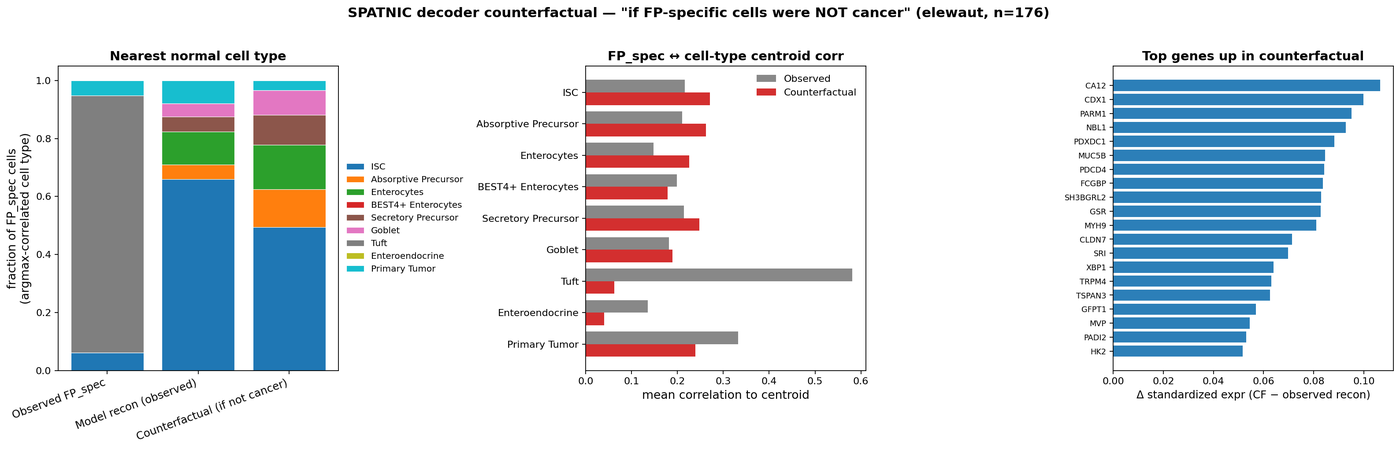

In [ ]:
# Decoder counterfactual gene attribution
Image(str(COMP / "spatnic_counterfactual/fpspec_counterfactual.png"))